# Lab Experiment 5: Linear Regression through Gradient Descent




In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)


Step 2: Load the Dataset

Load the student-mat.csv dataset (sep=";") and view its shape, columns, and sample rows.

In [2]:
df = pd.read_csv("student-mat.csv", sep=";")

print("Shape of dataset:", df.shape)
print("\nColumns:", list(df.columns))
df.head()

Shape of dataset: (395, 33)

Columns: ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### Step 3: Check for Missing Values

Before any preprocessing, we check whether the dataset has missing (`NaN`) values that need to be handled.

In [3]:
print("Missing values per column:\n")
print(df.isnull().sum().sum(), "total missing values in the dataset")
df.isnull().sum()

Missing values per column:

0 total missing values in the dataset


school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

The UCI Student Performance dataset is a clean, curated dataset — as confirmed above, there are **no missing values**, so no imputation is required.

Step 4: Encode Categorical Variables

Convert categorical features into numbers using binary encoding and one-hot encoding (drop_first=True) for multi-category variables.

In [4]:
df_enc = df.copy()

# Binary categorical columns -> map to 0/1
binary_maps = {
    "school": {"GP": 0, "MS": 1},
    "sex": {"F": 0, "M": 1},
    "address": {"U": 0, "R": 1},
    "famsize": {"LE3": 0, "GT3": 1},
    "Pstatus": {"T": 0, "A": 1},
    "schoolsup": {"no": 0, "yes": 1},
    "famsup": {"no": 0, "yes": 1},
    "paid": {"no": 0, "yes": 1},
    "activities": {"no": 0, "yes": 1},
    "nursery": {"no": 0, "yes": 1},
    "higher": {"no": 0, "yes": 1},
    "internet": {"no": 0, "yes": 1},
    "romantic": {"no": 0, "yes": 1},
}
for col, mapping in binary_maps.items():
    df_enc[col] = df_enc[col].map(mapping)

# Nominal categorical columns (>2 categories) -> one-hot encode
nominal_cols = ["Mjob", "Fjob", "reason", "guardian"]
df_enc = pd.get_dummies(df_enc, columns=nominal_cols, drop_first=True)

# Ensure one-hot columns are numeric (0/1) not True/False
bool_cols = df_enc.select_dtypes(include="bool").columns
df_enc[bool_cols] = df_enc[bool_cols].astype(int)

print("Shape after encoding:", df_enc.shape)
df_enc.head()

Shape after encoding: (395, 42)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,...,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,18,0,1,1,4,4,2,2,...,0,0,0,0,1,0,0,0,1,0
1,0,0,17,0,1,0,1,1,1,2,...,0,0,1,0,0,0,0,0,0,0
2,0,0,15,0,0,0,1,1,1,2,...,0,0,1,0,0,0,1,0,1,0
3,0,0,15,0,1,0,4,2,1,3,...,0,0,0,1,0,1,0,0,1,0
4,0,0,16,0,1,0,3,3,1,2,...,0,0,1,0,0,1,0,0,0,0


Step 5: Select Features and Target
Target (y): G3 (final grade)
Features (X): All remaining columns, including G1, G2, and other encoded features.

In [5]:
X = df_enc.drop(columns=["G3"]).values.astype(float)
y = df_enc["G3"].values.astype(float)
feature_names = df_enc.drop(columns=["G3"]).columns.tolist()

print("Feature matrix X shape:", X.shape)
print("Target vector y shape:", y.shape)
print("\nNumber of input features:", len(feature_names))

Feature matrix X shape: (395, 41)
Target vector y shape: (395,)

Number of input features: 41


### Step 6: Train-Test Split

We split the data into 80% training and 20% testing, using a fixed `random_state` for reproducibility.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 316
Testing samples: 79


Step 7: Feature Scaling

Scale the features using StandardScaler and add a bias (1s) column to the data for the intercept term.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Add bias (intercept) column of ones
X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled]
X_test_bias = np.c_[np.ones((X_test_scaled.shape[0], 1)), X_test_scaled]

# Reshape y to column vectors for matrix operations
y_train_col = y_train.reshape(-1, 1)
y_test_col = y_test.reshape(-1, 1)

print("X_train_bias shape:", X_train_bias.shape)
print("X_test_bias shape:", X_test_bias.shape)

X_train_bias shape: (316, 42)
X_test_bias shape: (79, 42)


Step 8: Define the Cost Function

Use the Mean Squared Error (MSE) cost function to measure the difference between predicted and actual values

In [8]:
def compute_cost(theta, X, y):
    m = len(y)
    predictions = X.dot(theta)
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost

Step 9: Implement Batch Gradient Descent

At each iteration, compute predictions, calculate the error and cost, find the gradient, and update theta using the learning rate.

In [9]:
def gradient_descent(X, y, learning_rate=0.05, iterations=1000):
    m = len(y)
    n_features = X.shape[1]
    theta = np.zeros((n_features, 1))
    cost_history = []

    for i in range(iterations):
        predictions = X.dot(theta)
        error = predictions - y

        cost = compute_cost(theta, X, y)
        cost_history.append(cost)

        gradients = (1 / m) * X.T.dot(error)
        theta = theta - learning_rate * gradients

    return theta, cost_history

### Step 10: Train the Model

In [10]:
learning_rate = 0.05
iterations = 1000

theta_final, cost_history = gradient_descent(
    X_train_bias, y_train_col,
    learning_rate=learning_rate,
    iterations=iterations
)

print(f"Final training cost (MSE/2): {cost_history[-1]:.4f}")
print(f"Intercept (theta_0): {theta_final[0, 0]:.4f}")
print("\nFirst 5 feature weights:")
for name, w in zip(feature_names[:5], theta_final[1:6, 0]):
    print(f"  {name}: {w:.4f}")

Final training cost (MSE/2): 1.4115
Intercept (theta_0): 10.3259

First 5 feature weights:
  school: 0.0293
  sex: 0.1866
  age: -0.1470
  address: -0.0342
  famsize: 0.0037


Step 11: Experiment with Different Learning Rates

Train the model with different learning rates to compare convergence. Small rates converge slowly, while large rates may overshoot or diverge.

learning_rate=0.001  -> final cost = 9.2697
learning_rate=0.01   -> final cost = 1.4302
learning_rate=0.05   -> final cost = 1.4115
learning_rate=0.1    -> final cost = 1.4115
learning_rate=0.5    -> final cost = 1.4115
learning_rate=1.0    -> final cost = DIVERGED (NaN)


c:\Users\DELL\AppData\Local\Programs\Python\Python314\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\DELL\AppData\Local\Temp\ipykernel_22800\2686879954.py:4: RuntimeWarning: overflow encountered in square
  cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
C:\Users\DELL\AppData\Local\Temp\ipykernel_22800\504450845.py:14: RuntimeWarning: overflow encountered in dot
  gradients = (1 / m) * X.T.dot(error)
C:\Users\DELL\AppData\Local\Temp\ipykernel_22800\504450845.py:14: RuntimeWarning: invalid value encountered in dot
  gradients = (1 / m) * X.T.dot(error)
C:\Users\DELL\AppData\Local\Temp\ipykernel_22800\504450845.py:15: RuntimeWarning: invalid value encountered in subtract
  theta = theta - learning_rate * gradients


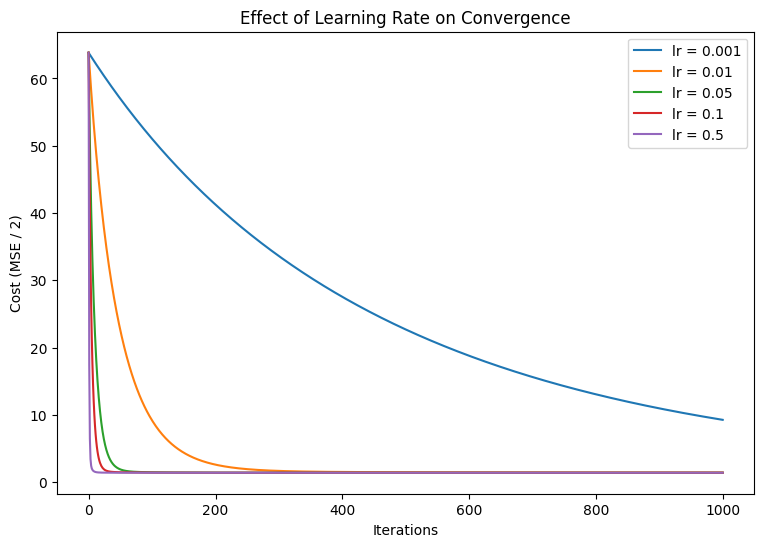

In [11]:
learning_rates = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0]
lr_cost_histories = {}

for lr in learning_rates:
    _, cost_hist = gradient_descent(X_train_bias, y_train_col, learning_rate=lr, iterations=iterations)
    lr_cost_histories[lr] = cost_hist
    final_cost = cost_hist[-1]
    status = "DIVERGED (NaN)" if np.isnan(final_cost) else f"{final_cost:.4f}"
    print(f"learning_rate={lr:<6} -> final cost = {status}")

# Plot only the well-behaved runs (a diverged run's huge/NaN values would swamp the y-axis)
plt.figure(figsize=(9, 6))
for lr, cost_hist in lr_cost_histories.items():
    if np.isfinite(cost_hist[-1]):
        plt.plot(cost_hist, label=f"lr = {lr}")

plt.xlabel("Iterations")
plt.ylabel("Cost (MSE / 2)")
plt.title("Effect of Learning Rate on Convergence")
plt.legend()
plt.show()

Observation:

0.001 converges very slowly.
0.01–0.5 converges smoothly.
1.0 diverges due to overshooting.

A moderate learning rate like 0.05 provides fast and stable convergence.

### Step 12: Plot Loss (Cost) vs. Number of Iterations — Chosen Model

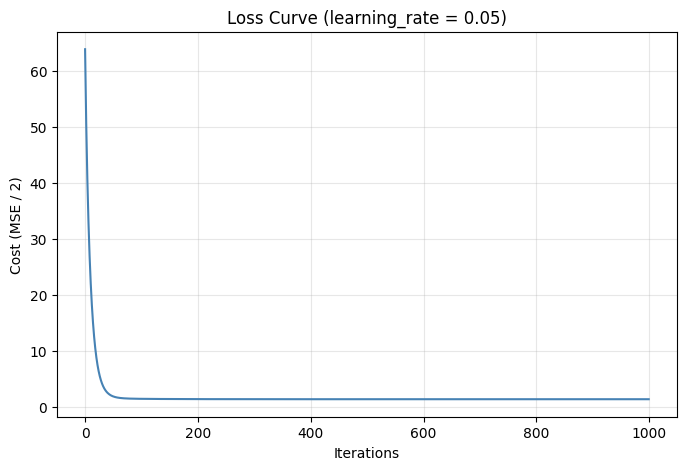

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(cost_history, color="steelblue")
plt.xlabel("Iterations")
plt.ylabel("Cost (MSE / 2)")
plt.title(f"Loss Curve (learning_rate = {learning_rate})")
plt.grid(alpha=0.3)
plt.show()

Step 13: Evaluate the Trained Model
Predict on the test set and evaluate using MAE, MSE, RMSE, and R² Score. The results are verified with sklearn.metrics.

In [13]:
y_pred_test = X_test_bias.dot(theta_final).flatten()
y_true_test = y_test_col.flatten()

# --- Manual computation ---
mae_manual = np.mean(np.abs(y_pred_test - y_true_test))
mse_manual = np.mean((y_pred_test - y_true_test) ** 2)
rmse_manual = np.sqrt(mse_manual)
ss_res = np.sum((y_true_test - y_pred_test) ** 2)
ss_tot = np.sum((y_true_test - np.mean(y_true_test)) ** 2)
r2_manual = 1 - (ss_res / ss_tot)

print("Manual computation:")
print(f"  MAE  : {mae_manual:.4f}")
print(f"  MSE  : {mse_manual:.4f}")
print(f"  RMSE : {rmse_manual:.4f}")
print(f"  R2   : {r2_manual:.4f}")

# --- Cross-check with sklearn ---
print("\nsklearn.metrics cross-check:")
print(f"  MAE  : {mean_absolute_error(y_true_test, y_pred_test):.4f}")
print(f"  MSE  : {mean_squared_error(y_true_test, y_pred_test):.4f}")
print(f"  RMSE : {np.sqrt(mean_squared_error(y_true_test, y_pred_test)):.4f}")
print(f"  R2   : {r2_score(y_true_test, y_pred_test):.4f}")

Manual computation:
  MAE  : 1.6473
  MSE  : 5.6577
  RMSE : 2.3786
  R2   : 0.7241

sklearn.metrics cross-check:
  MAE  : 1.6473
  MSE  : 5.6577
  RMSE : 2.3786
  R2   : 0.7241


### Step 14: Visualize Predicted vs. Actual Grades

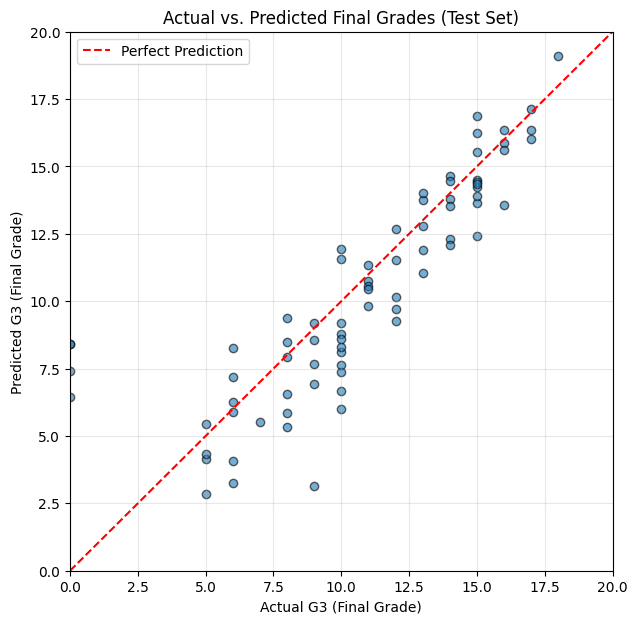

In [14]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true_test, y_pred_test, alpha=0.6, edgecolor="k")
lims = [0, 20]
plt.plot(lims, lims, color="red", linestyle="--", label="Perfect Prediction")
plt.xlabel("Actual G3 (Final Grade)")
plt.ylabel("Predicted G3 (Final Grade)")
plt.title("Actual vs. Predicted Final Grades (Test Set)")
plt.xlim(lims)
plt.ylim(lims)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

Step 15: Interpretation & Conclusion

Loss decreases and converges smoothly.
A moderate learning rate gives the best results.
G1 and G2 are the strongest predictors of G3.
Most predictions are close to the actual values.

Conclusion: Gradient Descent successfully trains the model, and the learning rate greatly affects performance.